In [72]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def create_sliding_windows(series, window_size, step=1):
    shape = ((series.shape[0] - window_size) // step + 1, window_size)
    strides = (series.strides[0] * step, series.strides[0])
    return np.lib.stride_tricks.as_strided(series, shape=shape, strides=strides)

def process_dataset(data_path, window_size=24):
    data = np.load(data_path)
    
    n1 = int(len(data) * 0.7)
    n2 = int(len(data) * 0.8)
    
    train_raw = data[:n1]
    val_raw = data[n1:n2]
    test_raw = data[n2:]
    
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled = scaler.transform(val_raw)
    test_scaled = scaler.transform(test_raw)
    
    def flatten_channels_to_windows(scaled_matrix):
        all_windows = []
        for col_idx in range(scaled_matrix.shape[1]):
            channel_series = scaled_matrix[:, col_idx]
            windows = create_sliding_windows(channel_series, window_size, step=1)
            all_windows.append(windows)
        return np.vstack(all_windows)

    train_windows = flatten_channels_to_windows(train_scaled)
    val_windows = flatten_channels_to_windows(val_scaled)
    test_windows = flatten_channels_to_windows(test_scaled)
    
    dataset_name = data_path.split('/')[-1].split('.')[0]
    np.save(f"data/{dataset_name}_train.npy", train_windows)
    np.save(f"data/{dataset_name}_val.npy", val_windows)
    np.save(f"data/{dataset_name}_test.npy", test_windows)
    
    print(f"[{dataset_name}] Train shape: {train_windows.shape}, Test shape: {test_windows.shape}")

# process_dataset("data/ETTh1.npy")
process_dataset("data/PEMS08.npy")
# process_dataset("data/electricity.npy") 
# process_dataset("data/ILI.npy")
# process_dataset("data/ETTh2.npy")
# process_dataset("data/ETTm1.npy")
# process_dataset("data/ETTm2.npy")


[PEMS08] Train shape: (88400, 24), Test shape: (25160, 24)


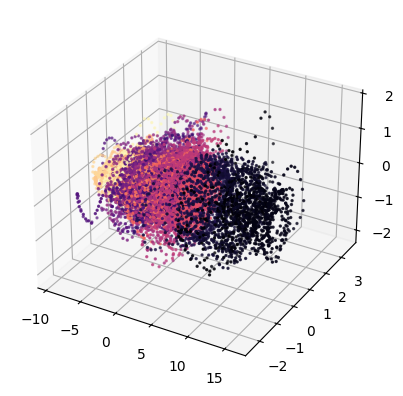

In [71]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

windows = np.load('data/ETTh1_strict.npy')
pca = PCA(n_components=3)
T = 15000
data_pca = pca.fit_transform(windows[:T])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=np.arange(T), cmap='magma', s=2)
plt.savefig("pca_strict_col_etth1.png")
plt.show()
